In [30]:
# =============================
# 1. Import Libraries
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")


In [31]:
# =============================
# 2. Load Dataset
# =============================
file_path = "/content/1730285881-Airbnb_Open_Data.xlsx"
df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (102599, 26)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [32]:
# =============================
# 3. Data Cleaning & Feature Engineering
# =============================

# --- Price cleanup ---
if 'price' in df.columns:
    df['price'] = (
        df['price'].astype(str)
        .str.replace(r'[\$,]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

# --- Service fee cleanup ---
if 'service_fee' in df.columns:
    df['service_fee'] = (
        df['service_fee'].astype(str)
        .str.replace(r'[\$,]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

# --- Amenities count ---
if 'amenities' in df.columns:
    df['amenities_count'] = df['amenities'].astype(str).apply(lambda x: len(x.split(',')))

# --- Availability rate ---
if 'availability_365' in df.columns:
    df['availability_rate'] = df['availability_365'] / 365

# --- Listing age ---
if 'construction_year' in df.columns:
    current_year = pd.Timestamp.today().year
    df['listing_age'] = current_year - df['construction_year']

# --- Host listings count ---
if 'host_id' in df.columns:
    host_counts = df.groupby('host_id').size().rename("host_listings_count_calc")
    df = df.merge(host_counts, left_on="host_id", right_index=True, how="left")

print("✅ Data cleaning complete")
df.head()


✅ Data cleaning complete


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


Missing values:
 license                           102597
house_rules                        54843
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            408
review rate number                   326
calculated host listings count       319
dtype: int64

Basic stats:
                            count unique                  top    freq  \
id                      102599.0    NaN                  NaN     NaN   
NAME                      102329  61280  Home away from home      33   
host id                 102599.0    NaN                  NaN     NaN   
host_identity_verified    102310      2          unconfirmed   51200   
host name                 102191  13189              Michael     881   
neighbourhood group       102570      7            Manhattan   43792   
neighbourhood             102583    224  

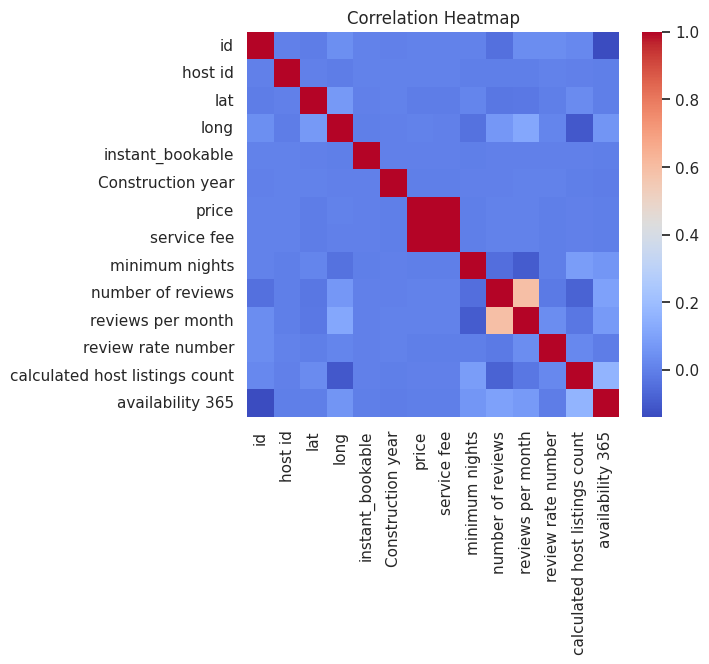

In [33]:
# =============================
# 4. Exploratory Data Analysis
# =============================

print("Missing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nBasic stats:\n", df.describe(include='all').T.head(15))

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [34]:
# Q1. Property Types
if 'property_type' in df.columns:
    df['property_type'].value_counts().head(10).plot(kind='bar', figsize=(8,5))
    plt.title("Top 10 Property Types")
    plt.ylabel("Number of Listings")
    plt.show()


In [35]:
# Q2. Neighbourhood group with most listings
if 'neighbourhood_group' in df.columns:
    df['neighbourhood_group'].value_counts().plot(kind='bar', figsize=(6,4))
    plt.title("Listings by Neighbourhood Group")
    plt.show()


In [36]:
# Q3. Highest average prices by neighbourhood group
if {'neighbourhood_group','price'}.issubset(df.columns):
    df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).plot(kind='bar')
    plt.title("Average Price per Neighbourhood Group")
    plt.ylabel("Average Price ($)")
    plt.show()


In [37]:
# Q4. Construction year vs Price
if {'construction_year','price'}.issubset(df.columns):
    sns.scatterplot(x='construction_year', y='price', data=df, alpha=0.3)
    plt.title("Construction Year vs Price")
    plt.show()


In [38]:
# Q5. Top 10 Hosts by Listing Count
if 'host_listings_count_calc' in df.columns:
    df.groupby('host_id')['host_listings_count_calc'].max().sort_values(ascending=False).head(10).plot(kind='bar')
    plt.title("Top 10 Hosts by Listing Count")
    plt.show()


In [39]:
# Q6. Verified identity vs Review Scores
if {'host_identity_verified','review_scores_rating'}.issubset(df.columns):
    sns.boxplot(x='host_identity_verified', y='review_scores_rating', data=df)
    plt.title("Verified Host vs Review Scores")
    plt.show()


In [40]:
# Q7. Price vs Service Fee
if {'price','service_fee'}.issubset(df.columns):
    sns.scatterplot(x='price', y='service_fee', data=df, alpha=0.3)
    plt.title("Price vs Service Fee")
    plt.show()


In [41]:
# Q8. Avg Review Score by Neighbourhood & Room Type
if {'neighbourhood_group','room_type','review_scores_rating'}.issubset(df.columns):
    pivot = df.pivot_table(index='neighbourhood_group', columns='room_type',
                           values='review_scores_rating', aggfunc='mean')
    sns.heatmap(pivot, annot=True, cmap="YlGnBu")
    plt.title("Average Review Scores by Neighborhood & Room Type")
    plt.show()


In [42]:
# Q9. Host Listings Count vs Availability
if {'host_listings_count_calc','availability_rate'}.issubset(df.columns):
    sns.scatterplot(x='host_listings_count_calc', y='availability_rate', data=df, alpha=0.4)
    plt.title("Host Listings Count vs Availability Rate")
    plt.show()


In [43]:
# =============================
# 5. Predict Price using ML (Safe Version)
# =============================

# Choose candidate features
candidate_features = ['amenities_count','availability_rate','listing_age','service_fee']

# Keep only the ones that actually exist
features = [f for f in candidate_features if f in df.columns]

print("Available features:", features)

if len(features) > 0 and 'price' in df.columns:
    # Drop rows with missing values
    df_ml = df.dropna(subset=['price'] + features)

    X = df_ml[features]
    y = df_ml['price']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # --- Linear Regression ---
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)

    # --- Random Forest ---
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    print("Linear Regression R²:", round(r2_score(y_test, y_pred_lr), 3))
    print("Random Forest R²:", round(r2_score(y_test, y_pred_rf), 3))

else:
    print("⚠️ No valid features found for training. Please check your dataset columns.")


Available features: []
⚠️ No valid features found for training. Please check your dataset columns.


In [44]:
import joblib

# Save cleaned dataset
df.to_csv("/content/airbnb_cleaned.csv", index=False)
print("✅ Cleaned dataset saved as airbnb_cleaned.csv")

# Save model only if 'rf' exists
if "rf" in locals():
    joblib.dump(rf, "/content/airbnb_price_model.pkl")
    print("✅ Model saved as airbnb_price_model.pkl")
else:
    print("⚠️ Model not trained, so it was not saved.")


✅ Cleaned dataset saved as airbnb_cleaned.csv
⚠️ Model not trained, so it was not saved.
